In [1]:
%matplotlib widget
import torch
import os
import copy
if torch.cuda.is_available():
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

import matplotlib.pyplot as plt

from diffSPH.operations import sph_operation, mod
from diffSPH.sampling import buildDomainDescription, sampleRegularParticles
from diffSPH.modules.eos import idealGasEOS
from diffSPH.modules.timestep import computeTimestep
from diffSPH.schema import getSimulationScheme
from diffSPH.reference.sod import buildSod_reference, sodInitialState, generateSod1D
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH
from diffSPH.reference.sod import plotSod
# from diffSPH.reference.linear import buildLinearWaveSimulation, runLinearWaveTest
from diffSPH.enums import *
from diffSPH.reference.sod import plotSod

In [93]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
# device = torch.device('cpu')
dtype = torch.float64

nx = 200
dim = 2
kernel = KernelType.B7
targetNeighbors = n_h_to_nH(4, dim)
CFL = 0.3
goalRadius = 0.8

nx = 256
rho0 = 1
E0 = 1
gamma = 5/3

scheme = SimulationScheme.CRKSPH
integrationScheme = IntegrationSchemeType.rungeKutta2
viscositySwitch = ViscositySwitch.NoneSwitch
supportScheme = AdaptiveSupportScheme.OwenScheme

domain = buildDomainDescription(l = 1, dim = dim, periodic = True, device = device, dtype = dtype)
domain.min = torch.tensor([0, 0], device = device, dtype = dtype)
domain.max = torch.tensor([1, 1], device = device, dtype = dtype)

simulator, SimulationSystem, solverConfig, integrator = getSimulationScheme(
     scheme, kernel, integrationScheme, 
     gamma, targetNeighbors, domain, 
     viscositySwitch=viscositySwitch, supportScheme = supportScheme)

In [94]:
particles_l = sampleRegularParticles(nx, domain, targetNeighbors, jitter = 0.0)

In [95]:
Pinitial = torch.ones_like(particles_l.positions[:,0], device = device, dtype = dtype) * E0 * rho0 ** gamma
rho = torch.ones_like(particles_l.positions[:,0], device = device, dtype = dtype) * rho0
v_initial = torch.zeros_like(particles_l.positions, device = device, dtype = dtype)

from diffSPH.modules.eos import idealGasEOS
from diffSPH.modules.compressible import CompressibleState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr

A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pinitial, rho = rho, gamma = gamma)
# v_initial = torch.zeros_like(particles_l.positions)

internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(v_initial, dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles_l.masses

simulationState = CompressibleState(
    positions = particles_l.positions,
    supports = particles_l.supports,
    masses = particles_l.masses * rho,
    densities = rho,        
    velocities = v_initial,
    
    kinds = torch.zeros_like(particles_l.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_l.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_l.positions.shape[0], device = device, dtype = torch.int32),

    internalEnergies = u_,
    totalEnergies = totalEnergy,
    entropies = A_,
    pressures = P_,
    soundspeeds = c_s,

    alphas = torch.ones_like(particles_l.densities),
    alpha0s = torch.ones_like(particles_l.densities)
)

from diffSPH.neighborhood import evaluateNeighborhood, filterNeighborhoodByKind, SupportScheme
neighborhood, neighbors = evaluateNeighborhood(simulationState, domain, kernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
numNeighbors = coo_to_csr(filterNeighborhoodByKind(simulationState, neighbors.neighbors, which = 'noghost')).rowEntries
densities = computeDensity(simulationState, kernel, neighbors.get('noghost'), SupportScheme.Gather, solverConfig)
print(densities.min(), densities.max(), densities.mean())

A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pinitial, rho = simulationState.densities, gamma = gamma)
simulationState.internalEnergies = u_


particleSystem = SimulationSystem(
        systemState = simulationState,
        domain = domain,
        neighborhoodInfo = neighborhood,
        t = 0
    )


timeLimit = 2
dt = computeTimestep(scheme, 1e-3, particleSystem.systemState, solverConfig, None)
# dt = torch.tensor(1e-4, dtype = dtype, device = device)
timesteps = int(timeLimit / dt)
simulationState = copy.deepcopy(particleSystem)
print(dt, timesteps)

tensor(1.0000, device='cuda:0', dtype=torch.float64) tensor(1.0000, device='cuda:0', dtype=torch.float64) tensor(1.0000, device='cuda:0', dtype=torch.float64)
tensor(0.0009, device='cuda:0', dtype=torch.float64) 2166


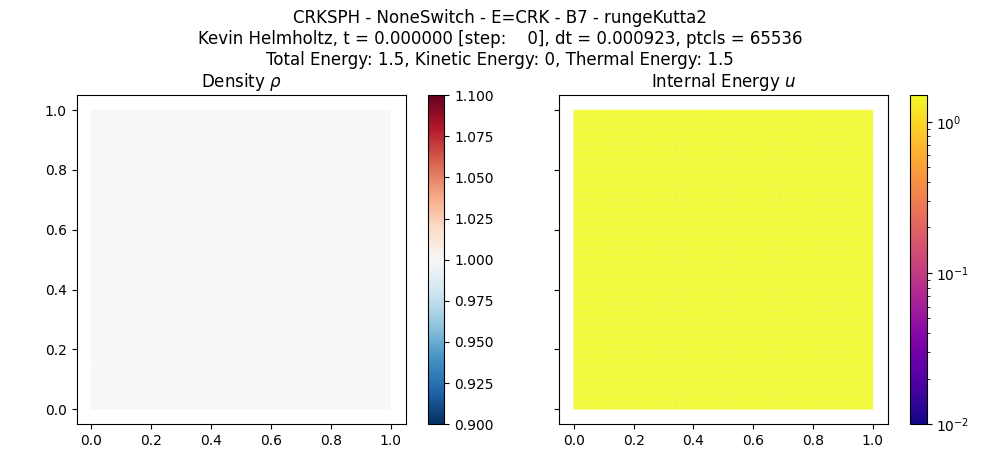

In [96]:
from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH, evaluateOptimalSupportOwen

fluidParticles = simulationState.systemState

fig, axis = plt.subplots(1, 2, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)

s = 0.1
densityPlotState = visualizeParticles(fig, axis[0,0],
                     particles = fluidParticles, 
                     domain = domain, 
                     quantity = fluidParticles.densities, 
                     which = 'fluid',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = False,
                    #  scaling = 'sym',
                     cmap = 'RdBu_r',
                     midPoint=1.5,
                     title='Density $\\rho$',
                     markerSize = s,
                     gridVisualization=False, gridResolution=256)

internalEnergyPlotState = visualizeParticles(fig, axis[0,1],
                     particles = fluidParticles, 
                     domain = domain, 
                     quantity = fluidParticles.internalEnergies, 
                     which = 'fluid',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = False,
                     cmap = 'plasma',
                     title='Internal Energy $u$',
                     scaling = 'log',
                     vmin = 1e-2,
                     markerSize = s,
                     gridVisualization=False, gridResolution=256)

# for ax in axis.flatten():
    # ax.set_xlim(-1, 1)
    # ax.set_ylim(-1,1)
kineticEnergy = 0.5 * (torch.linalg.norm(simulationState.systemState.velocities, dim = -1) **2 * simulationState.systemState.masses).sum()
thermalEnergy = (simulationState.systemState.internalEnergies * simulationState.systemState.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy
    
    
fig.suptitle(f'{solverConfig["schemeName"]}\nKevin Helmholtz, t = {simulationState.t:2f} [step: {0:4d}], dt = {dt:.3g}, ptcls = {len(simulationState.systemState.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
# fig.suptitle(f'{solverConfig["schemeName"]}\nSedov-Taylor Explosion, t = {simulationState.t:2f} [step: {0:4d}], dt = {dt:.3g}, ptcls = {len(simulationState.systemState.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')

fig.tight_layout()


In [97]:
from diffSPH.modules.CRKSPH import computeGeometricMoments, computeCRKTerms, correctedKernel, correctedGradientKernel
from typing import Union, Optional
from dataclasses import dataclass
import dataclasses
# from diffSPH.modules.compressible import CompressibleParticleSet, BaseSPHSystem
from diffSPH.neighborhood import DomainDescription, SparseCOO
from diffSPH.kernels import SPHKernel
import torch
from diffSPH.operations import sph_op
from diffSPH.sphOperations.shared import get_i, get_j, mod_distance, getSupport, scatter_sum, product
from diffSPH.modules.eos import idealGasEOS
from diffSPH.neighborhood import NeighborhoodInformation
from diffSPH.integrationSchemes.util import integrateQ

from diffSPH.modules.compressible import CompressibleState
from diffSPH.operations import sph_op, SPHOperation
from diffSPH.schemes.states.wcsph import WeaklyCompressibleState
from diffSPH.neighborhood import SparseNeighborhood, PrecomputedNeighborhood, SupportScheme, evalKernel, evalKernelGradient
from diffSPH.operations import DivergenceMode, GradientMode, Operation, LaplacianMode
from typing import Dict, Tuple



@dataclass
class KernelMoments:
    m_0: torch.Tensor
    m_1: torch.Tensor
    m_2: torch.Tensor
    dm_0dgamma: torch.Tensor
    dm_1dgamma: torch.Tensor
    dm_2dgamma: torch.Tensor

def computeGeometricMoments(
        particles: Union[CompressibleState, WeaklyCompressibleState],
        kernel: SPHKernel,
        neighborhood: Tuple[SparseNeighborhood, PrecomputedNeighborhood],
        supportScheme: SupportScheme = SupportScheme.Scatter,
        config: Dict = {}):

    i = neighborhood[0].row
    j = neighborhood[0].col

    x_ij = neighborhood[1].x_ij    
    V_j = particles.apparentArea[j]
    
    W_ij = evalKernel(neighborhood[1], supportScheme=supportScheme, combined=True)
    gradW_ij = evalKernelGradient(neighborhood[1], supportScheme=supportScheme, combined=True)

    dyadicProduct = lambda a, b: torch.einsum('i...j,i...k->i...jk', a, b)
    delta = lambda i, j: 1 if i == j else 0
    nu = x_ij.shape[1]
    dtype = x_ij.dtype
    device = x_ij.device
    eye = torch.eye(nu, dtype = dtype, device = device)
    
    m_0 = V_j * W_ij
    m_1 = x_ij * (V_j * W_ij).view(-1, 1)
    m_2 = dyadicProduct(x_ij, x_ij) * (V_j * W_ij).view(-1, 1, 1)
        
    dm_0dgamma = (V_j).view(-1, 1) * gradW_ij
    dm_1dgamma = (V_j).view(-1, 1, 1) * (dyadicProduct(x_ij, gradW_ij) + W_ij.view(-1,1,1) * eye)
    # x_ij^alpha delta^{beta, gamma} + delta^{alpha, gamma} x_ij^beta
    
    # dm_2dgamma = (V_j).view(-1, 1, 1, 1) * (dyadicProduct(dyadicProduct(x_ij, x_ij), gradW_ij))
    dm_2dgamma = torch.zeros(x_ij.shape[0], nu, nu, nu, dtype = dtype, device = device)
    for alpha in range(nu):
        for beta in range(nu):
            for gamma in range(nu):
                gradTerm = x_ij[:, alpha] * x_ij[:, beta] * gradW_ij[:, gamma]
                deltaA = x_ij[:,alpha] * delta(beta, gamma)
                deltaB = delta(alpha, gamma) * x_ij[:, beta]
                kernelTerm = W_ij * (deltaA + deltaB)
                dm_2dgamma[..., gamma, alpha, beta] = V_j * (gradTerm + kernelTerm)
    
    # print(diagonalTerm.shape)
    
    # print(m_0.shape, m_1.shape, m_2.shape, dm_0dgamma.shape, dm_1dgamma.shape, dm_2dgamma.shape)
    
    
    m_0 = scatter_sum(m_0, i, dim = 0, dim_size = particles.positions.shape[0])
    m_1 = scatter_sum(m_1, i, dim = 0, dim_size = particles.positions.shape[0])
    m_2 = scatter_sum(m_2, i, dim = 0, dim_size = particles.positions.shape[0])
    
    dm_0dgamma = scatter_sum(dm_0dgamma, i, dim = 0, dim_size = particles.positions.shape[0])
    dm_1dgamma = scatter_sum(dm_1dgamma, i, dim = 0, dim_size = particles.positions.shape[0])
    dm_2dgamma = scatter_sum(dm_2dgamma, i, dim = 0, dim_size = particles.positions.shape[0])
    
    return KernelMoments(
        m_0 = m_0,
        m_1 = m_1,
        m_2 = m_2,
        dm_0dgamma = dm_0dgamma,
        dm_1dgamma = dm_1dgamma,
        dm_2dgamma = dm_2dgamma
    )


def computeCRKTerms(moments: KernelMoments, num_nbrs: torch.Tensor):
    m_0 = moments.m_0
    m_1 = moments.m_1
    m_2 = moments.m_2
    dm_0dgamma = moments.dm_0dgamma
    dm_1dgamma = moments.dm_1dgamma
    dm_2dgamma = moments.dm_2dgamma


    m_2_det = torch.det(m_2).abs()
    m_2_inv = torch.linalg.pinv(m_2)
    is_singular = torch.where(m_2_det < 1e-6, 1.0, 0.0)
    # print(f'Is singular: {is_singular.sum()}')

    # pinv_test = torch.einsum('nij, nij -> nij', m_2_inv, m_2)
    # print(f'Pinv test: {pinv_test}')
    #     # Eq. 12.
    # ai = 1.0/(m0 - dot(temp_vec, m1, d))
    A = 1 / (m_0 - torch.einsum('nij, ni, nj -> n', m_2_inv, m_1, m_1))
    # # Eq. 13.
    # mat_vec_mult(m2inv, m1, d, bi)
    # for gam in range(d):
    #     bi[gam] = -bi[gam]
    B = - torch.einsum('nij, nj -> ni', m_2_inv, m_1)

    gradA = torch.zeros_like(dm_0dgamma)
    gradB = torch.zeros_like(dm_1dgamma)

    # print(gradA.shape, gradB.shape)
    nu = gradA.shape[1]
    gradATerm1 = dm_0dgamma
    gradATerm2 = torch.einsum('nij, nj, nki -> nk', m_2_inv, m_1, dm_1dgamma)
    # gradATerm3 = torch.einsum('nij, ncj, ni -> nc', m_2_inv, dm_1dgamma, m_1)
    gradATerm4 = torch.einsum('nil, nklm, nmj, nj, ni -> nk', m_2_inv, dm_2dgamma, m_2_inv, m_1, m_1)
    gradA = - (A **2).view(-1,1) * ( gradATerm1 - 2 * gradATerm2 + gradATerm4)

    gradBTerm1 = torch.einsum('nij, nkj -> nki', m_2_inv, dm_1dgamma)
    gradBTerm2 = torch.einsum('nil, nklm, nmj, nj -> nki', m_2_inv, dm_2dgamma, m_2_inv, m_1)
    gradB = -gradBTerm1 + gradBTerm2

    # num_nbrs = coo_to_csr(actualNeighbors).rowEntries

    mask = (num_nbrs < 2) #| (is_singular > 0.0)

    # if N_NBRS < 2 or is_singular > 0.0:
    # d_ai[d_idx] = 1.0
    # for i in range(d):
    #     d_gradai[d * d_idx + i] = 0.0
    #     d_bi[d * d_idx + i] = 0.0
    #     for j in range(d):
    #         d_gradbi[d2 * d_idx + d * i + j] = 0.0
    
    A[mask] = 1.0
    for i in range(nu):
        gradA[mask, i] = 0.0
        B[mask, i] = 0.0
        for j in range(nu):
            gradB[mask, i, j] = 0.0
            
    return A, B, gradA, gradB

def computeCRKVolume(
        particles: Union[CompressibleState, WeaklyCompressibleState],
        kernel: SPHKernel,
        neighborhood: Tuple[SparseNeighborhood, PrecomputedNeighborhood],
        supportScheme: SupportScheme = SupportScheme.Scatter,
        config: Dict = {}):
    

    i = neighborhood[0].row
    j = neighborhood[0].col
    
    W_ij = evalKernel(neighborhood[1], supportScheme=supportScheme, combined=True)
    
    return 1 / scatter_sum(W_ij, i, dim = 0, dim_size=particles.positions.shape[0])

In [98]:
from diffSPH.plotting import visualizeParticles, updatePlot
import matplotlib.pyplot as plt
from diffSPH.operations import sph_op
from diffSPH.kernels import getSPHKernelv2
from BasisConvolution.convLayerv3 import BasisConvLayer

config = solverConfig
wrappedKernel = config['kernel']
particles = simulationState.systemState


def evalDensity(state, neighborhood, domains, config):
    quantity = torch.ones_like(state.densities)

    return sph_op(
        state, state, domains, getSPHKernelv2('Wendland2'), neighborhood, quantity = state.velocities, supportScheme='gather', operation = 'density'
    )

neighborhood, neighbors = evaluateNeighborhood(particles, domain, wrappedKernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=neighborhood, computeHessian=False, computeDkDh=False, only_j = False)
filteredNeighborhood = filterNeighborhoodByKind(particles, neighbors.neighbors, 'noghost')
# filtered_csr = coo_to_csr(filteredNeighborhood)
# print(f'Filtered neighborhood: {filtered_csr}')

rho = evalDensity(particles, filteredNeighborhood, domain, config)


In [99]:
jitteredState = copy.deepcopy(particles)
jitteredState.positions[:,0] += torch.randn_like(jitteredState.positions[:,0]) * 0.05 * particles.supports
# jitteredState.positions[:,1] += torch.randn_like(jitteredState.positions[:,1]) * 0.05 * particles.supports

neighborhood, neighbors = evaluateNeighborhood(jitteredState, domain, wrappedKernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=neighborhood, computeHessian=False, computeDkDh=False, only_j = False)
filteredNeighborhood = filterNeighborhoodByKind(jitteredState, neighbors.neighbors, 'noghost')
jitteredState.numNeighbors = coo_to_csr(filteredNeighborhood).rowEntries

In [100]:
# from diffSPH.modules.CRKSPH import computeCRKVolume, computeGeometricMoments, computeCRKTerms, computeCRKDensity, computeVelocityTensor, computeCRKdvdt, computeCRKdudt

jitteredState.apparentArea = computeCRKVolume(jitteredState, wrappedKernel, neighbors.get('noghost'), SupportScheme.Gather, config)
kernelMoments = computeGeometricMoments(jitteredState, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, config)
jitteredState.A, jitteredState.B, jitteredState.gradA, jitteredState.gradB = computeCRKTerms(kernelMoments, jitteredState.numNeighbors)

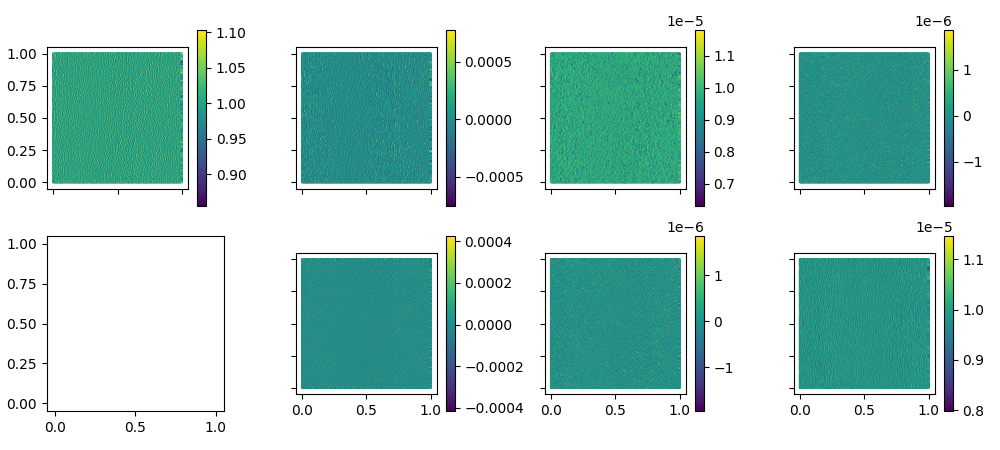

In [101]:
from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH, evaluateOptimalSupportOwen

fluidParticles = simulationState.systemState

fig, axis = plt.subplots(2, 4, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)

s = 1
kernelMoment_m0 = visualizeParticles(fig, axis[0,0],
                     particles = fluidParticles, 
                     domain = domain, 
                     quantity = kernelMoments.m_0, 
                     which = 'fluid',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = False,
                     cmap = 'viridis',
                     markerSize = s,
                     gridVisualization=False, gridResolution=256)

kernelMoment_m1x = visualizeParticles(fig, axis[0,1],
                     particles = fluidParticles, 
                     domain = domain, 
                     quantity = kernelMoments.m_1[:,0], 
                     which = 'fluid',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = False,
                     cmap = 'viridis',
                     markerSize = s,
                     gridVisualization=False, gridResolution=256)
kernelMoment_m1y = visualizeParticles(fig, axis[1,1],
                     particles = fluidParticles, 
                     domain = domain, 
                     quantity = kernelMoments.m_1[:,1],
                     which = 'fluid',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = False,
                     cmap = 'viridis',
                     markerSize = s,
                     gridVisualization=False, gridResolution=256)

for i in range(2):
    for j in range(2):
        kernelMoment_m2 = visualizeParticles(fig, axis[i,j+2],
                         particles = fluidParticles, 
                         domain = domain, 
                         quantity = kernelMoments.m_2[:,i,j], 
                         which = 'fluid',
                         visualizeBoth=False,
                         kernel = solverConfig['kernel'],
                         plotDomain = False,
                         cmap = 'viridis',
                         markerSize = s,
                         gridVisualization=False, gridResolution=256)


# for ax in axis.flatten():
    # ax.set_xlim(-1, 1)
    # ax.set_ylim(-1,1)
# kineticEnergy = 0.5 * (torch.linalg.norm(simulationState.systemState.velocities, dim = -1) **2 * simulationState.systemState.masses).sum()
# thermalEnergy = (simulationState.systemState.internalEnergies * simulationState.systemState.masses).sum()
# totalEnergy = kineticEnergy + thermalEnergy
    
    
# fig.suptitle(f'{solverConfig["schemeName"]}\nKevin Helmholtz, t = {simulationState.t:2f} [step: {0:4d}], dt = {dt:.3g}, ptcls = {len(simulationState.systemState.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
# fig.suptitle(f'{solverConfig["schemeName"]}\nSedov-Taylor Explosion, t = {simulationState.t:2f} [step: {0:4d}], dt = {dt:.3g}, ptcls = {len(simulationState.systemState.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')

fig.tight_layout()


In [102]:
from diffSPH.neighborhood import PrecomputedNeighborhood, evalKernel
from diffSPH.sphOperations.shared import get_i, get_j, mod_distance, getSupport, scatter_sum, product
# from diffSPH.kernelFunctions import evalKernel

def correctedKernel(A, B, kernelValues : PrecomputedNeighborhood, supportScheme: SupportScheme = SupportScheme.SuperSymmetric, xji: bool = False):
    fac = -1 if xji else 1
    prod = torch.einsum('...i, ...i -> ...', B, fac * kernelValues.x_ij)
    W_ij = evalKernel(kernelValues, supportScheme=supportScheme, combined=True)
    return A * (1 + prod) * W_ij

def correctedGradientKernel(A, B, gradA, gradB, kernelValues : PrecomputedNeighborhood, supportScheme: SupportScheme = SupportScheme.SuperSymmetric, xji: bool = False):
    fac = -1 if xji else 1
    W_ij = evalKernel(kernelValues, supportScheme=supportScheme, combined=True)
    gradW_ij = evalKernelGradient(kernelValues, supportScheme=supportScheme, combined=True)
    
    dotProd = lambda a, b: torch.einsum('...i, ...j -> ...', a, b)
    dot_ii = lambda a, b: torch.einsum('...i, ...i -> ...', a, b)
    
    # term 1 :A B^k W_ab
    # term 2: A (1 + B^i x_ij^i) gradW
    # term 3: (1 + B^i x_ij^i) W (partial_k A)
    # term 4: A (x_ij^i partial_k B^i) W

    x_ij = kernelValues.x_ij
    # if xji:
        # x_ij = -x_ij

    term1 = A.view(-1,1) * B * W_ij.view(-1,1)
    term2 = fac * (A * (1 + fac * dot_ii(B, x_ij))).view(-1,1) * gradW_ij
    term3 = (1 + fac * dot_ii(B, x_ij)).view(-1,1) * W_ij.view(-1,1) * gradA
    term4 = fac * A.view(-1,1) * (torch.einsum('...a,...ca -> ...c', x_ij, gradB)) * W_ij.view(-1,1)

    # print(f'GradW_ij: {gradW_ij.shape}, A: {A.shape}, B: {B.shape}, kernelValues.x_ij: {kernelValues.x_ij.shape}')
    # print(f'Term1: {term1}')
    # print(f'Term2: {term2}')
    # print(f'Term3: {term3}')
    # print(f'Term4: {term4}')

    return term1 + term2 + term3 + term4, term1, term2, term3, term4

    # firstTerm = (A * (1 + dotProd(B, fac * kernelValues.x_ij))).view(-1,1) * gradW_ij
    # secondTerm = gradA * ((1 + dotProd(B, fac * kernelValues.x_ij)) * W_ij).view(-1,1)
    # thirdTerm = (torch.einsum('...ca,...a -> ...c', gradB, fac * kernelValues.x_ij) + B) * (W_ij * A).view(-1,1)

    # return firstTerm + secondTerm + thirdTerm

neighs = neighbors.get('noghost')
gradW_ij, a, b, c, d = correctedGradientKernel(jitteredState.A[i], jitteredState.B[i], jitteredState.gradA[i], jitteredState.gradB[i], neighs[1])

print(gradW_ij)

tensor([[-6.4190e+00, -1.7851e+00],
        [-3.9466e+02, -2.8013e+02],
        [-1.0770e+04, -3.7310e+03],
        ...,
        [ 1.8734e+04,  6.6255e+03],
        [ 1.2949e+03,  9.6255e+02],
        [ 2.4572e-02,  6.5230e-03]], device='cuda:0', dtype=torch.float64)


In [103]:
print(jitteredState.A[i])
print(jitteredState.A[j])

tensor(0.9646, device='cuda:0', dtype=torch.float64)
tensor(0.9646, device='cuda:0', dtype=torch.float64)


In [104]:
Q = (jitteredState.positions[:,0]).clone()

In [110]:
neighs = neighbors.get('noghost')

i = neighs[0].row
j = neighs[0].col
V_j = jitteredState.apparentArea[j]
m_i = jitteredState.masses[i]

Q_j = Q[j]

W_ij = correctedKernel(jitteredState.A[i], jitteredState.B[i], neighs[1])
W_ji = correctedKernel(jitteredState.A[j], jitteredState.B[j], neighs[1], xji=True)
W = (W_ij + W_ji) / 2
W = W_ij
# should be m_j for particles from the same material
# however, this would lead to problems on the hydrostatic case
# but that shouldnt happen?

Q_RK = scatter_sum(Q_j * V_j * W, i, dim = 0, dim_size=jitteredState.positions.shape[0])
# termB = scatter_sum(V_j * V_j * W_ij, i, dim = 0, dim_size=jitteredState.positions.shape[0])

Q_grad_RK = torch.zeros_like(jitteredState.positions)


gradW_ij, ai, bi, ci, di = correctedGradientKernel(jitteredState.A[i], jitteredState.B[i], jitteredState.gradA[i], jitteredState.gradB[i], neighs[1])
gradW_ji, aj, bj, cj, dj = correctedGradientKernel(jitteredState.A[j], jitteredState.B[j], jitteredState.gradA[j], jitteredState.gradB[j], neighs[1], xji=True)
gradW = -gradW_ji
gradW = (gradW_ij - gradW_ji) / 2
# gradW = gradW_ij

Q_grad_RK = scatter_sum((Q_j * V_j)[:,None] * gradW, i, dim = 0, dim_size=jitteredState.positions.shape[0])


Q_interpolated = sph_op(
        jitteredState, jitteredState, domain, getSPHKernelv2('Wendland2'), neighbors.neighbors, quantity = Q, supportScheme='gather', operation = 'interpolate'
    )

Q_grad = sph_op(
        jitteredState, jitteredState, domain, getSPHKernelv2('Wendland2'), neighbors.neighbors, quantity = Q, supportScheme='gather', operation = 'gradient', gradientMode = 'naive'
    )


In [111]:
gradDiff = gradW_ij - gradW_ji
print(f'Gradients: {gradW_ij.shape}, {gradW_ji.shape}, {gradW.shape}, {Q_grad_RK.shape}, {Q_grad.shape}')
print(f'Gradients diff: {gradDiff.min()}, {gradDiff.max()}, {gradDiff.mean()}')

Gradients: torch.Size([3119190, 2]), torch.Size([3119190, 2]), torch.Size([3119190, 2]), torch.Size([65536, 2]), torch.Size([65536, 2])
Gradients diff: -6566175.613175732, 6566175.613175732, 3.5351675542199305e-13


In [112]:
print(f'ai: {ai.min()}, {ai.max()}, {ai.mean()}, {ai.std()}')
print(f'aj: {aj.min()}, {aj.max()}, {aj.mean()}, {aj.std()}')
print(f'a_diff: {(ai - aj).min()}, {(ai - aj).max()}, {(ai - aj).mean()}, {(ai - aj).std()}')
print(f'bi: {bi.min()}, {bi.max()}, {bi.mean()}, {bi.std()}')
print(f'bj: {bj.min()}, {bj.max()}, {bj.mean()}, {bj.std()}')
print(f'b_diff: {(bi - bj).min()}, {(bi - bj).max()}, {(bi - bj).mean()}, {(bi - bj).std()}')
print(f'ci: {ci.min()}, {ci.max()}, {ci.mean()}, {ci.std()}')
print(f'cj: {cj.min()}, {cj.max()}, {cj.mean()}, {cj.std()}')
print(f'di: {di.min()}, {di.max()}, {di.mean()}, {di.std()}')
print(f'dj: {dj.min()}, {dj.max()}, {dj.mean()}, {dj.std()}')


ai: -1633152.1230934584, 1559390.9229050255, 3.871011994733339, 51364.970201574644
aj: -1633152.1230934584, 1559390.9229050255, 3.871011994733286, 51364.970201574644
a_diff: -1186504.9327784646, 1186504.93277845, 6.688154832307976e-14, 51106.38507301057
bi: -3425344.7031717566, 3354340.764532653, -0.12391818882213541, 702802.0739763014
bj: -3425344.7031717566, 3354340.764532653, -0.12391818882214438, 702802.0739763014
b_diff: -6710698.195044564, 6710698.195044564, 1.146540828395653e-13, 1405107.7633805303
ci: -1822463.3803740644, 1688101.062866782, -6.023039388989743, 47641.30428180626
cj: -1822463.3803740644, 1688101.062866782, -6.0230393889896785, 47641.30428180626
di: -1511758.8871161211, 1407782.08977109, 2.1341288495458652, 59094.717508186
dj: -1511758.887116139, 1407782.08977109, 2.134128849545567, 59094.717508186


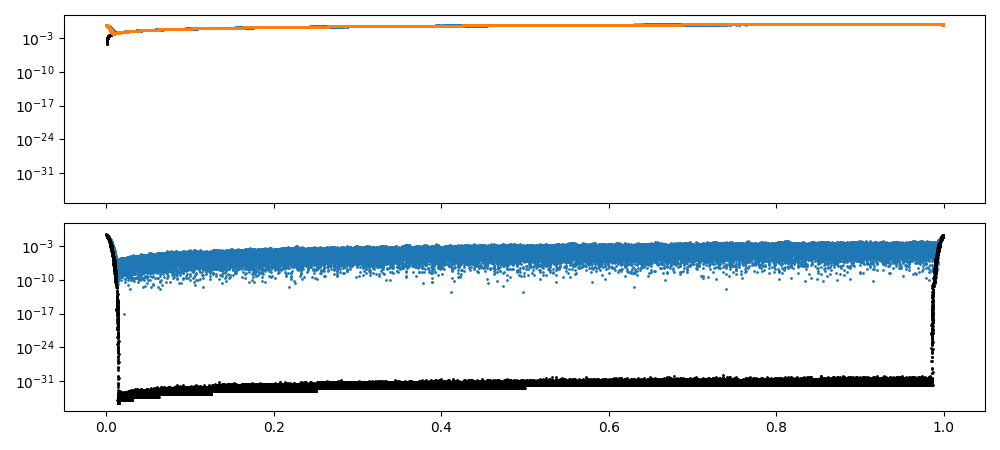

In [113]:
fig, axis = plt.subplots(2, 1, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)

axis[0,0].scatter(jitteredState.positions[:,0].cpu().numpy(), Q_interpolated.cpu().numpy(), s=1, cmap='viridis')
axis[0,0].scatter(jitteredState.positions[:,0].cpu().numpy(), Q.cpu().numpy(), s=1, cmap='viridis', c = 'black')
axis[0,0].scatter(jitteredState.positions[:,0].cpu().numpy(), Q_RK.cpu().numpy(), s=1, cmap='viridis')

axis[1,0].scatter(jitteredState.positions[:,0].cpu().numpy(), (Q_interpolated.cpu().numpy() - Q.cpu().numpy())**2, s=1, cmap='viridis')
axis[1,0].scatter(jitteredState.positions[:,0].cpu().numpy(), (Q_RK.cpu().numpy() - Q.cpu().numpy())**2, s=1, cmap='viridis', c = 'black')

# axis[1,0].set_xlim(0.1, 0.9)
axis[1,0].set_yscale('log')

fig.tight_layout()

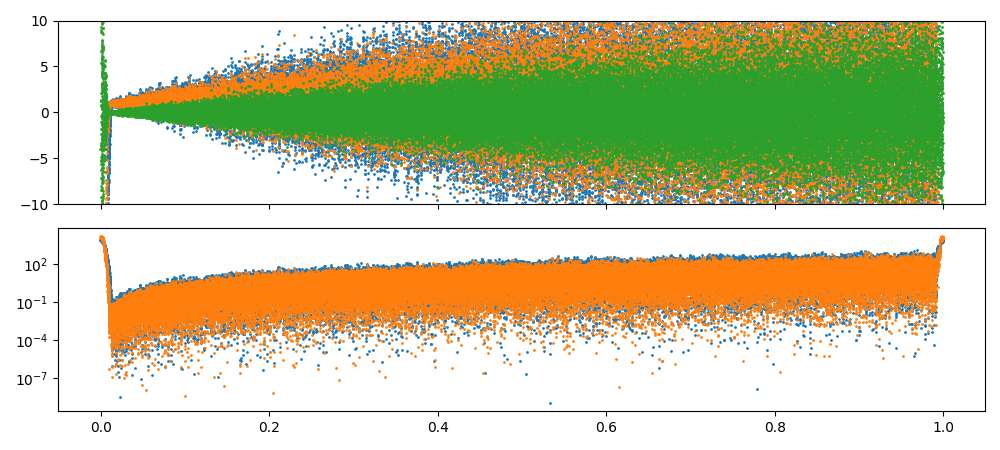

In [114]:
fig, axis = plt.subplots(2, 1, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=False)

axis[0,0].scatter(jitteredState.positions[:,0].cpu().numpy(), Q_grad[:,0].cpu().numpy(), s=1, cmap='viridis')
axis[0,0].scatter(jitteredState.positions[:,0].cpu().numpy(), Q_grad_RK[:,0].cpu().numpy(), s=1, cmap='viridis')

axis[1,0].scatter(jitteredState.positions[:,0].cpu().numpy(), (Q_grad[:,0].cpu().numpy() - 1)**2, s=1, cmap='viridis')
axis[1,0].scatter(jitteredState.positions[:,0].cpu().numpy(), (Q_grad_RK[:,0].cpu().numpy() - 1)**2, s=1, cmap='viridis')

# axis[0,0].scatter(jitteredState.positions[:,0].cpu().numpy(), Q_grad[:,1].cpu().numpy(), s=1, cmap='viridis')
axis[0,0].scatter(jitteredState.positions[:,0].cpu().numpy(), Q_grad_RK[:,1].cpu().numpy(), s=1, cmap='viridis')

# axis[1,0].set_xlim(0.1, 0.9)
axis[1,0].set_yscale('log')

axis[0,0].set_ylim(-10,10)


fig.tight_layout()

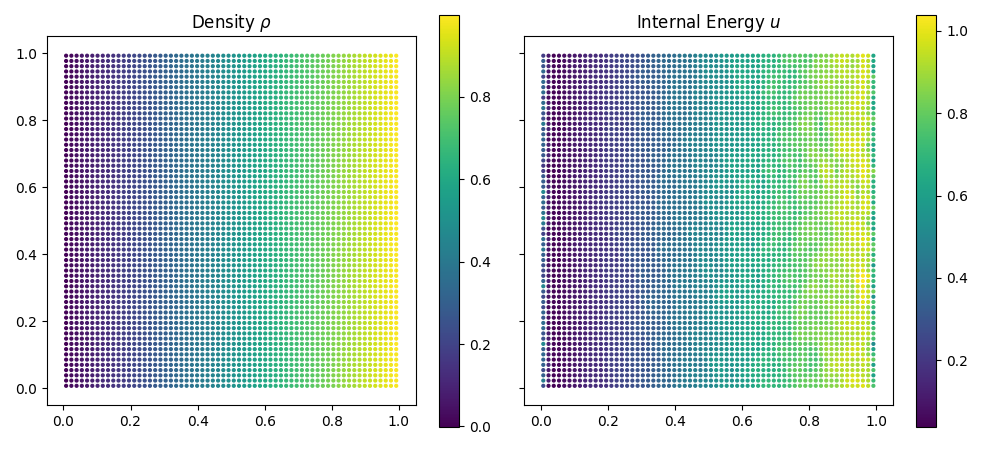

In [18]:




from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH, evaluateOptimalSupportOwen

fluidParticles = simulationState.systemState

fig, axis = plt.subplots(1, 2, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)

s = 4
densityPlotState = visualizeParticles(fig, axis[0,0],
                     particles = fluidParticles, 
                     domain = domain, 
                     quantity = Q, 
                     which = 'fluid',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = False,
                     cmap = 'viridis',
                    #  midPoint=1.5,
                     title='Density $\\rho$',
                     markerSize = s,
                     gridVisualization=False, gridResolution=256)

internalEnergyPlotState = visualizeParticles(fig, axis[0,1],
                     particles = fluidParticles, 
                     domain = domain, 
                     quantity = Q_interpolated, 
                     which = 'fluid',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = False,
                     cmap = 'viridis',
                     title='Internal Energy $u$',
                     markerSize = s,
                     gridVisualization=False, gridResolution=256)

# for ax in axis.flatten():
    # ax.set_xlim(-1, 1)
    # ax.set_ylim(-1,1)
# kineticEnergy = 0.5 * (torch.linalg.norm(simulationState.systemState.velocities, dim = -1) **2 * simulationState.systemState.masses).sum()
# thermalEnergy = (simulationState.systemState.internalEnergies * simulationState.systemState.masses).sum()
# totalEnergy = kineticEnergy + thermalEnergy
    
    
# fig.suptitle(f'{solverConfig["schemeName"]}\nKevin Helmholtz, t = {simulationState.t:2f} [step: {0:4d}], dt = {dt:.3g}, ptcls = {len(simulationState.systemState.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
# fig.suptitle(f'{solverConfig["schemeName"]}\nSedov-Taylor Explosion, t = {simulationState.t:2f} [step: {0:4d}], dt = {dt:.3g}, ptcls = {len(simulationState.systemState.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')

fig.tight_layout()


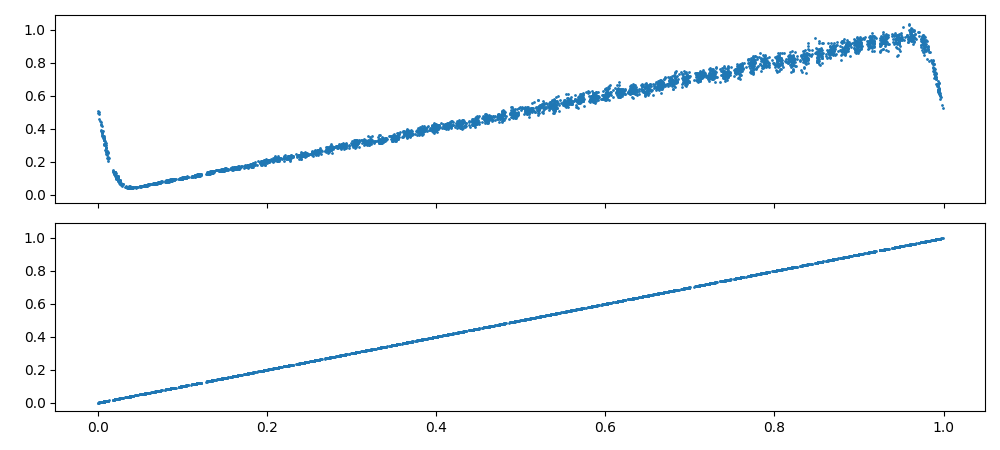

In [19]:
fig, axis = plt.subplots(2, 1, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)

axis[0,0].scatter(jitteredState.positions[:,0].cpu().numpy(), Q_interpolated.cpu().numpy(), s=1, cmap='viridis')
axis[1,0].scatter(jitteredState.positions[:,0].cpu().numpy(), Q.cpu().numpy(), s=1, cmap='viridis')

fig.tight_layout()